In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Figure1: general willingness 
6 figures

In [7]:
# load data for general willingness 

df1_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/1_willingness_final.xlsx')
df1_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/1_willingness_v2.4.xlsx')
df1_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/1_willingness_v3_new.xlsx')

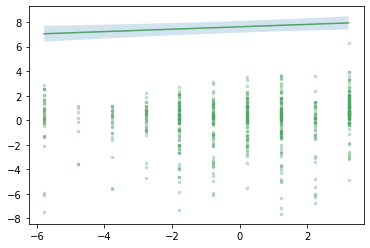

In [6]:
partial = pd.read_csv("/Users/carriesmac/Desktop/partial_residuals.csv")

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df1_predictions_severity.csv")

plt.scatter(
    partial["perceived_severity_c"],
    partial["partial_residual"],
    color="#52a167",
    s=6,
    alpha=0.3
)

plt.plot(pred["x"], pred["predicted"], color="#52a167")
plt.fill_between(pred["x"], pred["conf.low"], pred["conf.high"], alpha=0.2)

In [8]:
# load adjusted data for general willingness 

#df1_v1p_c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/1_willingness_final.xlsx')
df1_v2p_c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/1_willingness_v2.4_c.xlsx')
#df1_v2c_c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/1_willingness_v3_new.xlsx')

In [ ]:
# 26-05-05 calculate subject-level mean per level and sig. predictor 

def calculate_subject_summary(df, subject_id_col, numeric_cols, categorical_cols):
    """
    Aggregates long-format data to subject-level.
    Calculates mean for numeric columns and keeps the first entry for categorical.
    """
    
    # 1. Define the aggregation dictionary
    # Numeric variables get the mean; Categorical variables get the first instance
    agg_dict = {col: 'mean' for col in numeric_cols}
    agg_dict.update({col: 'first' for col in categorical_cols})
    
    # 2. Group by Subject_ID and apply the aggregations
    df_subject = df.groupby(subject_id_col, as_index=False).agg(agg_dict)
    
    return df_subject

# --- Example Usage ---
# numeric_vars = ['perceived_severity', 'response_score', 'age']
# categorical_vars = ['Gender', 'source', 'clinical_stage']

# df_final = calculate_subject_summary(
#     df=df_long, 
#     subject_id_col='Subject_ID', 
#     numeric_cols=numeric_vars, 
#     categorical_cols=categorical_vars
# )

In [45]:
# Use this if you want a mean for EACH scenario a subject did
df_sub = df1_v1p.groupby(['Subject_ID','response_type'], as_index=False)['Response'].mean()

df_global = df_sub.groupby('response_type', as_index=False)['Response'].mean()

In [46]:
df_global

,response_type,Response
0,diagnosis,6.532828
1,treatment,8.050505


In [47]:
# Use this if you want a mean for EACH scenario a subject did
df_sub = df1_v1p.groupby(['Subject_ID','Gender_corr'], as_index=False)['Response'].mean()

df_global = df_sub.groupby('Gender_corr', as_index=False)['Response'].mean()

In [48]:
df_global

,Gender_corr,Response
0,Female,7.159639
1,Male,7.976562


In [17]:
df1_v1p

,Unnamed: 0,Subject_ID,Age,Gender_corr,Number_of_children,Max_child_age,City_scale,Family_income_ordinal,Previous_AI_knowledge_score,Digital_usage_score,Response,response_type,Education_level_new,Story_ID,Years_of_education
0,0,16,35,Female,1,2.0,3,4,4,3,10,diagnosis,5,1,15
1,1,17,38,Female,1,2.0,3,4,2,3,8,diagnosis,2,1,12
2,2,19,26,Female,1,0.0,1,4,2,4,7,diagnosis,6,1,17
3,3,20,38,Male,1,2.0,3,4,2,6,6,diagnosis,6,1,17
4,4,21,34,Female,1,0.0,4,3,2,3,4,diagnosis,3,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,787,281,55,Female,2,17.0,3,4,2,3,4,diagnosis,6,4,17
788,788,284,34,Female,1,6.0,3,3,2,2,10,diagnosis,4,4,16
789,789,285,39,Female,3,12.0,1,4,2,4,10,diagnosis,2,4,12
790,790,286,34,Female,2,5.0,3,0,2,1,5,diagnosis,3,4,15


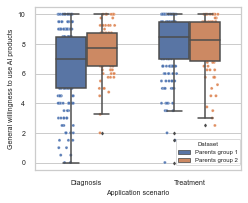

In [21]:
# fig1a willingness box (v1p+v2p), width = 3.7inch


# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "response_type"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "response_type": "clinical_stage",
           "Response": "response_score"
       })
)
df1_subject["clinical_stage"] = df1_subject["clinical_stage"].map({"diagnosis": "Diagnosis", "treatment": "Treatment"})
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df1_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.7, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot
sns.boxplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2}
)

# Stripplot with subject-level points
sns.stripplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(handles[0:2], 
           ["Parents group 1", "Parents group 2"], 
           title="Dataset",
           loc = 'lower right',
           bbox_to_anchor=(1.01, 0.01),
           prop={'size': 6}, 
           title_fontsize=6,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Application scenario")
plt.ylabel("General willingness to use AI products")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("df1_v1p+v2p_boxer_plots.svg", bbox_inches='tight',format="svg")
plt.show()


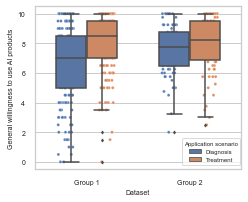

In [6]:
# fig1a_v3_revised (2026.04.30)
# Categorized by Dataset (source) instead of clinical_stage

# ---------- Aggregate to subject-level ----------
# (Data cleaning stays the same to maintain your data structure)
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "response_type"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "response_type": "clinical_stage",
           "Response": "response_score"
       })
)
df1_subject["clinical_stage"] = df1_subject["clinical_stage"].map({"diagnosis": "Diagnosis", "treatment": "Treatment"})
df1_subject["source"] = "Group 1"

df2_subject = (
    df1_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# --- REVISED CATEGORICAL ORDERING ---
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.7, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot: SWAPPED x and hue
sns.boxplot(
    x="source",             # Now categorized by Dataset on X-axis
    y="response_score",
    hue="clinical_stage",   # Now color-coded by Stage
    data=df_subject,
    order=source_order,     # Use source_order for X
    hue_order=stage_order,  # Use stage_order for color
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2}
)

# Stripplot: SWAPPED x and hue
sns.stripplot(
    x="source",
    y="response_score",
    hue="clinical_stage",
    data=df_subject,
    order=source_order,
    hue_order=stage_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

# Updated legend labels to reflect Clinical Stage
plt.legend(handles[0:2], 
           ["Diagnosis", "Treatment"], 
           title="Application scenario",
           loc = 'lower right',
           bbox_to_anchor=(1.01, 0.01),
           prop={'size': 6}, 
           title_fontsize=6,
           frameon=True,
           facecolor='white',
           framealpha=0.7
)

# Revised Labels
plt.xlabel("Dataset")
plt.ylabel("General willingness to use AI products")

plt.savefig("Fig2A_v3.svg", bbox_inches='tight', format="svg")
plt.show()

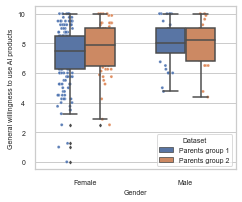

In [22]:
# fig1b gender box plot (v1p+v2p), width = 3.7inch 

# update above figure with data from v2p as well (not sig.), 27-01-26
# fig1b

# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Gender_corr": "Gender",
           "Response": "response_score"
       })
)
#df1_subject["Gender"] = df1_subject["Gender"].map({1: "Diagnosis", 2: "Treatment"})
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df1_v2p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"Gender_corr": "Gender"})
)
#df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Female", "Male"]
source_order = ["Group 1", "Group 2"]
df_subject["Gender"] = pd.Categorical(df_subject["Gender"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.6, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot
sns.boxplot(
    x="Gender",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2},
    #palette= "pastel"
)

# Stripplot with subject-level points
sns.stripplot(
    x="Gender",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1,
    #palette= "pastel"
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(handles[0:2], 
           ["Parents group 1", "Parents group 2"], 
           title="Dataset",
           loc = 'lower right',
           #bbox_to_anchor=(1.01, 0.01),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Gender")
plt.ylabel("General willingness to use AI products")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("fig1b_df1_v1p+v2p_gender_boxer_plots.svg", bbox_inches='tight', format="svg")
plt.show()


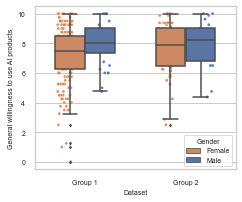

In [9]:
# fig1b gender box plot (v1p+v2p) - Categorized by Dataset - SWAPPED COLORS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Aggregate to subject-level ----------
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Gender_corr": "Gender",
           "Response": "response_score"
       })
)
df1_subject["source"] = "Group 1"

df2_subject = (
    df1_v2p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"Gender_corr": "Gender"})
)
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
gender_order = ["Female", "Male"]
source_order = ["Group 1", "Group 2"]
df_subject["Gender"] = pd.Categorical(df_subject["Gender"], categories=gender_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.6, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# --- IMPLEMENTING COLOR SWAP ---
# We define a specific mapping. By default, Female would be color1 (blue), Male color2 (orange).
# We explicitly assign them the opposite colors using Seaborn's color_palette names
# or direct hex codes. Here we use color names that correspond to the default palette.
custom_palette = {"Female": "C1", "Male": "C0"}  # C1 is typically Orange, C0 is typically Blue.

# Boxplot
sns.boxplot(
    x="source",
    y="response_score",
    hue="Gender",
    data=df_subject,
    order=source_order,
    hue_order=gender_order,
    palette=custom_palette,  # Apply custom colors
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2}
)

# Stripplot
sns.stripplot(
    x="source",
    y="response_score",
    hue="Gender",
    data=df_subject,
    order=source_order,
    hue_order=gender_order,
    palette=custom_palette,  # Apply SAME custom colors
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

# Legend stays the same as the hue definition handles the colors
plt.legend(handles[0:2], 
           ["Female", "Male"], 
           title="Gender",
           loc = 'lower right',
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,
           facecolor='white',
           framealpha=0.7
)

# Labels
plt.xlabel("Dataset")
plt.ylabel("General willingness to use AI products")

plt.savefig("Fig2b_v3.svg", bbox_inches='tight', format="svg")
plt.show()

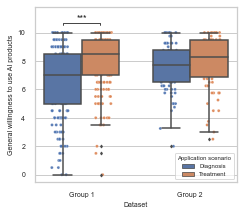

In [36]:
# fig1a_v3_revised (2026.04.30)
# Categorized by Dataset with Significance Annotation (p < .001)

# ... [Aggregation code same as before] ...
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "response_type"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "response_type": "clinical_stage",
           "Response": "response_score"
       })
)
df1_subject["clinical_stage"] = df1_subject["clinical_stage"].map({"diagnosis": "Diagnosis", "treatment": "Treatment"})
df1_subject["source"] = "Group 1"

df2_subject = (
    df1_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# --- REVISED CATEGORICAL ORDERING ---
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.4, 3)) # Narrower width to keep groups nearby

plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial', 'axes.titlesize': 8,
    'axes.labelsize': 7, 'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7
})

# Boxplot
ax = sns.boxplot(
    x="source", y="response_score", hue="clinical_stage", data=df_subject,
    order=source_order, hue_order=stage_order,
    width=0.7, dodge=True, whis=1.5, fliersize=2, boxprops={'zorder': 2}
)

# Stripplot
sns.stripplot(
    x="source", y="response_score", hue="clinical_stage", data=df_subject,
    order=source_order, hue_order=stage_order,
    dodge=True, jitter=0.15, size=3, edgecolor="w", linewidth=0.25, alpha=0.9, zorder=1
)

# ---------- Significance Annotation (Group 1: p < .001) ----------
x1, x2 = -0.17, 0.17 
# Determine height based on data
y_max = df_subject['response_score'].max()
y, h, col = y_max + 0.5, 0.2, 'k'

# Draw bracket
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=col)
# Add triple stars for p < .001
plt.text((x1+x2)*.5, y+h, "***", ha='center', va='bottom', color=col, fontsize=9)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], ["Diagnosis", "Treatment"], title="Application scenario",
           loc='lower right', prop={'size': 6}, title_fontsize=6,
           frameon=True, facecolor='white', framealpha=0.7)

# Labels
plt.xlabel("Dataset")
plt.ylabel("General willingness to use AI products")
plt.ylim(top=y_max + 1.8) # Adjusting headroom for the taller star stack

plt.tight_layout()
plt.savefig("fig1a_dataset_sig_annotated.svg", bbox_inches='tight', format="svg")
plt.show()

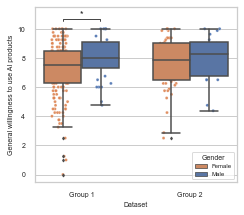

In [17]:
# fig1b gender box plot - Grouped closer together
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ... [Aggregation code remains identical] ...
# ---------- Aggregate to subject-level ----------
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Gender_corr": "Gender",
           "Response": "response_score"
       })
)
df1_subject["source"] = "Group 1"

df2_subject = (
    df1_v2p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"Gender_corr": "Gender"})
)
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
gender_order = ["Female", "Male"]
source_order = ["Group 1", "Group 2"]
df_subject["Gender"] = pd.Categorical(df_subject["Gender"], categories=gender_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")

# REDUCED figure width from 3.6 to 2.8 to bring the x-axis groups closer
plt.figure(figsize=(3.4, 3)) 

plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial', 'axes.titlesize': 8,
    'axes.labelsize': 7, 'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7
})

custom_palette = {"Female": "C1", "Male": "C0"}

# Boxplot: Increased width slightly to 0.7 to fill the space better
ax = sns.boxplot(
    x="source", y="response_score", hue="Gender", data=df_subject,
    order=source_order, hue_order=gender_order, palette=custom_palette,
    width=0.7, dodge=True, whis=1.5, fliersize=2, boxprops={'zorder': 2}
)

# Stripplot
sns.stripplot(
    x="source", y="response_score", hue="Gender", data=df_subject,
    order=source_order, hue_order=gender_order, palette=custom_palette,
    dodge=True, jitter=0.15, size=3, edgecolor="w", linewidth=0.25, alpha=0.9, zorder=1
)

# ---------- Significance Annotation (Group 1) ----------
# Adjusted slightly for the new width
x1, x2 = -0.17, 0.17 
y, h, col = df_subject['response_score'].max() + 0.5, 0.2, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=col)
plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize=9)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], ["Female", "Male"], title="Gender",
           loc='lower right', prop={'size': 6}, title_fontsize=7,
           frameon=True, facecolor='white', framealpha=0.7)

plt.xlabel("Dataset")
plt.ylabel("General willingness to use AI products")
plt.ylim(top=df_subject['response_score'].max() + 1.5)

# Adjust margins to remove excess white space
plt.tight_layout()

plt.savefig("fig1b_gender_nearby_plots.svg", bbox_inches='tight', format="svg")
plt.show()

6.814190221518987


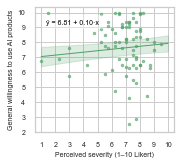

In [15]:
# fig1c v2p severity, width = 2.46


pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df1_predictions_severity.csv")


df_avg1 = (
    df1_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 7.48008
slope = 0.09819
x_mean = df_avg1['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig2c_df1_v2p_severity.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg1['perceived_severity'], df_avg1['response_score'], color='#52a167',alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='#52a167', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='#52a167', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 11))
plt.yticks(range(2,11))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.08, 0.9, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


In [14]:
df1_v2p_c.columns

Index(['...1', 'Subject_ID', 'Age', 'Gender_corr', 'Number_of_children',
       'Max_child_age', 'If_adult_child', 'Mean_age_children',
       'Education_level', 'Family_income_ordinal',
       'Previous_AI_knowledge_score', 'Digital_usage_score',
       'Previous_medical_knowledge', 'disease', 'experience',
       'perceived_severity', 'response_type', 'response_score',
       'Years_of_education', 'Age_c', 'Previous_medical_knowledge_c',
       'perceived_severity_c', 'Previous_AI_knowledge_score_c',
       'Digital_usage_score_c', 'Years_of_education_c', 'Max_child_age_c'],
      dtype='object')

6.814190221518987


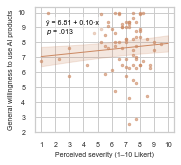

In [33]:
# fig1c v2p severity, width = 2.46


pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df1_predictions_severity.csv")


df_avg1 = (
    df1_v2p_c.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity_c": "mean",
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 7.48008
slope = 0.09819
x_mean = df_avg1['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig2c_df1_v2p_severity_c.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg1['perceived_severity_c'] + x_mean, df_avg1['response_score'], color='#cc8963',alpha=0.6, s=6)

plt.plot(pred['x'] + x_mean, pred['predicted'], color='#cc8963', linewidth=1)
plt.fill_between(pred['x'] + x_mean, pred['conf.low'], pred['conf.high'], color='#cc8963', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 11))
plt.yticks(range(2,11))


formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .013"
)

plt.text(
    0.08, 0.90,
    formula_text,
    transform=plt.gca().transAxes,
    fontsize=7,
    color="black",
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


In [160]:
adjusted = pd.read_csv('fig2c_severity_subject_means.csv')
adjusted

,Subject_ID,x_centered,x_raw,adjusted_response,partial_residual,observed_response
0,18,0.968354,7.75,7.907840,0.292372,8.750
1,20,1.468354,8.25,7.723870,0.108402,6.750
2,22,0.968354,7.75,7.632234,0.016767,6.875
3,24,0.718354,7.50,8.024564,0.409097,10.000
4,26,-1.031646,5.75,7.545342,-0.070126,7.625
...,...,...,...,...,...,...
73,124,0.218354,7.00,7.856318,0.240851,9.375
74,126,1.218354,8.00,7.864165,0.248697,8.750
75,130,2.218354,9.00,7.776198,0.160731,8.000
76,131,0.718354,7.50,7.544409,-0.071059,7.125


6.814190221518987


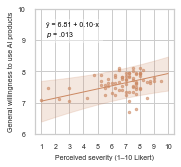

In [164]:
# fig2c v2p severity, width = 2.46
# with adjusted data (26-07-25)

adjusted = pd.read_csv('fig2c_severity_subject_means.csv')

pred = pd.read_csv('fig2c_severity_prediction_line.csv')


df_avg1 = (
    df1_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 7.48008
slope = 0.09819
x_mean = df_avg1['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig2c_df1_v2p_severity_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(adjusted['x_raw'], adjusted['adjusted_response'], color='#cc8963',alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='#cc8963', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='#cc8963', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 11))
plt.yticks(range(6,11))


formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .013"
)

plt.text(
    0.08, 0.90,
    formula_text,
    transform=plt.gca().transAxes,
    fontsize=7,
    color="black",
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


6.67191568216


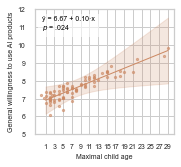

In [168]:
# fig1d v2p max child age, width = 2.46 [⚠️omit same plot for v2p-rep now, since same data]
# using adjusted data (2026-07-25)


adjusted = pd.read_csv("fig2d_max_child_age_subject_means.csv")
pred = pd.read_csv("fig2d_max_child_age_prediction_line.csv")

intercept = 7.48008
slope = 0.09928
x_mean = 8.140253
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig2d_df1_v2p_maximal_child_age_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

df_avg_age = (
    df1_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Max_child_age": "mean",
        "response_score": "mean"
    })
)

plt.scatter(adjusted['x_raw'], adjusted['adjusted_response'], color='#cc8963', alpha=0.6, s=5)

plt.plot(pred['x_raw'], pred['predicted'], color='#cc8963', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='#cc8963', alpha=0.2)
plt.xlabel("Maximal child age")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 31,2))
plt.yticks(range(5,1,1))


formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .024"
)

plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)


plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


In [169]:
pred.describe()

,x_centered,x_raw,predicted,std.error,conf.low,conf.high
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,6.859747,15.000000,8.301134,0.482326,7.353913,9.248355
std,8.514693,8.514693,0.845330,0.223529,0.487577,1.255724
min,-7.140253,1.000000,6.911228,0.243577,6.147555,7.674902
25%,-0.140253,8.000000,7.606181,0.298185,7.127831,8.084532
50%,6.859747,15.000000,8.301134,0.388863,7.539819,9.062449
75%,13.859747,22.000000,8.996087,0.651209,7.717204,10.274970
max,20.859747,29.000000,9.691040,0.938457,7.848042,11.534038


In [7]:
df_raw

,disease,Previous_AI_knowledge_score,perceived_severity,response_type,Gender_corr,response_score,Digital_usage_score,Subject_ID,Age,group
0,pneumonia,2,7,diagnosis,Female,9,6,18,42,Parents
1,pneumonia,2,7,treatment,Female,9,6,18,42,Parents
2,pneumonia,1,8,diagnosis,Female,5,2,20,44,Parents
3,pneumonia,1,8,treatment,Female,7,2,20,44,Parents
4,pneumonia,2,7,diagnosis,Female,6,3,22,36,Parents
...,...,...,...,...,...,...,...,...,...,...
891,developmental_delay,3,6,treatment,Female,6,5,75,30,Clinicians
892,developmental_delay,4,8,diagnosis,Male,10,5,80,53,Clinicians
893,developmental_delay,4,8,treatment,Male,9,5,80,53,Clinicians
894,developmental_delay,2,6,diagnosis,Female,2,3,82,39,Clinicians


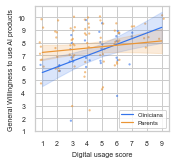

In [14]:
# --- 1. Load Data ---
# pred: the summary/prediction data from R
# df_raw: your separate long-format raw data
pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/df1_v5_predictions_interaction.csv")
df_raw = pd.read_excel("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/v5_data/1_combined_data_willingness_v5.xlsx") 

df_sub = df_raw.groupby(['group', 'Subject_ID'], as_index=False).agg({
    'Digital_usage_score': 'mean', 
    'response_score': 'mean'
})

# --- 3. Styling & Color Mapping ---
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Ensure these keys match your 'group' column exactly
group_colors = {
    "Clinicians": "#3474eb", 
    "Parents": "#eb9534"     
}

plt.figure(figsize=(2.46, 2.3))

# --- 4. Plot Aggregated Scatters ---
for g_label, g_color in group_colors.items():
    subset = df_sub[df_sub["group"] == g_label]
    
    # Jitter is still recommended even with 1 point per subject 
    # to show overlap if multiple people have the same mean score.
    jitter_x = np.random.uniform(-0.18, 0.18, size=len(subset))
    jitter_y = np.random.uniform(-0.18, 0.18, size=len(subset))
    
    plt.scatter(
        subset["Digital_usage_score"] + jitter_x, 
        subset["response_score"] + jitter_y, 
        color=g_color,
        alpha=0.6,          # Slightly higher alpha since there are fewer points
        s=5,               
        edgecolor='none',
        label='_nolegend_'
    )

# --- 5. Plot Regression Lines & CIs ---
x_common = np.linspace(pred["x_raw"].min(), pred["x_raw"].max(), 100)

for g_label in pred["group"].unique():
    df_g = pred[pred["group"] == g_label]
    current_color = group_colors.get(g_label, "black")
    
    interp_pred = np.interp(x_common, df_g["x_raw"], df_g["predicted"])
    interp_low = np.interp(x_common, df_g["x_raw"], df_g["conf.low"])
    interp_high = np.interp(x_common, df_g["x_raw"], df_g["conf.high"])
    
    plt.plot(x_common, interp_pred, color=current_color, label=g_label, linewidth=1.2)
    plt.fill_between(x_common, interp_low, interp_high, color=current_color, alpha=0.18)

# --- 6. Final Formatting ---
plt.xlabel("Digital usage score")
plt.ylabel("General Willingness to use AI products")
plt.xticks(range(1, 10))
plt.yticks(range(1, 11))
plt.xlim(0.5, 9.5)

plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.8, prop={'size': 6})

plt.tight_layout()
plt.savefig('fig1e_v2_single_point_per_sub.svg', bbox_inches='tight')
plt.show()

Index(['Subject_ID', 'group', 'x', 'adjusted_response', 'n_obs',
       'Digital_usage_score'],
      dtype='object')
Index(['x', 'predicted', 'conf.low', 'conf.high', 'group',
       'Digital_usage_score'],
      dtype='object')
['Clinicians' 'Parents']
['Clinicians' 'Parents']


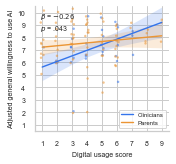

In [2]:
# Fig2e new version on adjusted data (26-08-11)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Load adjusted participant-level data + model predictions
# ============================================================

df_sub = pd.read_csv(
    "/Users/carriesmac/Desktop/Results_in_excel待写/"
    "v2c_v2p_combined_group_analysis/"
    "group_digital_adjusted_points_rawX.csv"
)

pred = pd.read_csv(
    "/Users/carriesmac/Desktop/Results_in_excel待写/"
    "v2c_v2p_combined_group_analysis/"
    "group_digital_predictions_rawX.csv"
)

# Check labels / columns
print(df_sub.columns)
print(pred.columns)

print(df_sub["group"].unique())
print(pred["group"].unique())


# ============================================================
# 2. Styling
# ============================================================

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

group_colors = {
    "Clinicians": "#3474eb",
    "Parents": "#eb9534"
}

plt.figure(figsize=(2.46, 2.3))


# ============================================================
# 3. Plot adjusted participant-level scatter points
# ============================================================

# Make jitter reproducible
rng = np.random.default_rng(123)

for g_label, g_color in group_colors.items():

    subset = df_sub[
        df_sub["group"] == g_label
    ].copy()

    # Small jitter to avoid overlapping points
    jitter_x = rng.uniform(
        -0.12,
        0.12,
        size=len(subset)
    )

    jitter_y = rng.uniform(
        -0.12,
        0.12,
        size=len(subset)
    )

    plt.scatter(
        subset["Digital_usage_score"] + jitter_x,
        subset["adjusted_response"] + jitter_y,  #changed to 'adjusted_response'
        color=g_color,
        alpha=0.55,
        s=6,
        edgecolor="none",
        label="_nolegend_",
        zorder=2
    )


# ============================================================
# 4. Plot model-predicted interaction lines + 95% CI
# ============================================================

for g_label in pred["group"].unique():

    df_g = (
        pred[pred["group"] == g_label]
        .sort_values("Digital_usage_score")
        .copy()
    )

    current_color = group_colors.get(
        g_label,
        "black"
    )

    plt.plot(
        df_g["Digital_usage_score"],
        df_g["predicted"],
        color=current_color,
        linewidth=1.4,
        label=g_label,
        zorder=4
    )

    plt.fill_between(
        df_g["Digital_usage_score"],
        df_g["conf.low"],
        df_g["conf.high"],
        color=current_color,
        alpha=0.18,
        linewidth=0,
        zorder=1
    )


# ============================================================
# 5. Optional interaction annotation
# ============================================================

plt.text(
    0.04,
    0.96,
    r"$\beta$ = $-0.26$" + "\n" + r"$p$ = .043",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=7
)


# ============================================================
# 6. Final formatting
# ============================================================

plt.xlabel("Digital usage score")
plt.ylabel("Adjusted general willingness to use AI")

# Digital usage range in your combined analysis
plt.xticks(range(1, 10))

plt.yticks(range(1, 11))

plt.xlim(
    0.5,
    9.5
)

plt.ylim(
    0.5,
    10.5
)

plt.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.8,
    prop={"size": 6}
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "fig2e_group_digital_interaction_adjusted.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

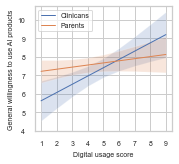

In [348]:
# fig1e v2p_v2c digital usage (interaction), width = 2.46 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load predictions from R ---
pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/df1_v5_predictions_interaction.csv")

sns.set(style="whitegrid")

# add raw data of two participant groups: ⬇️

# Rename columns if needed
# Should have: 'x', 'predicted', 'conf.low', 'conf.high', 'group'
#print(pred.head())

# --- Create a common x grid for all groups ---
x_common = np.linspace(pred["x_raw"].min(), pred["x_raw"].max(), 100)

aligned_preds = []

# --- Interpolate predictions and CI for each group onto same x-grid ---
for g, df_g in pred.groupby("group"):
    interp_pred = np.interp(x_common, df_g["x_raw"], df_g["predicted"])
    interp_low = np.interp(x_common, df_g["x_raw"], df_g["conf.low"])
    interp_high = np.interp(x_common, df_g["x_raw"], df_g["conf.high"])
    
    aligned_preds.append(
        pd.DataFrame({
            "x_raw": x_common,
            "predicted": interp_pred,
            "conf.low": interp_low,
            "conf.high": interp_high,
            "group": g
        })
    )

pred_aligned = pd.concat(aligned_preds, ignore_index=True)

# --- Plot with aligned CIs ---
sns.set(style="whitegrid")
plt.figure(figsize=(2.5, 2.3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})


for g, df_g in pred_aligned.groupby("group"):
    plt.plot(df_g["x_raw"], df_g["predicted"], label=g, linewidth=1)
    plt.fill_between(df_g["x_raw"], df_g["conf.low"], df_g["conf.high"], alpha=0.2)

plt.xlabel("Digital usage score")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 10))
plt.yticks(range(4,11))


handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], 
           ["Clinicans", "Parents"], 
           #title="Dataset",
           loc = 'upper left',
           #bbox_to_anchor=(1.01, 0.01),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)


plt.tight_layout()  # leave room on right for legend

plt.savefig('fig2e_df1_v5_interaction.svg', bbox_inches='tight')
plt.show()


### Figure2: accuracy results

In [44]:
### load data of all df2 

df2_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/2_accuracy_final.xlsx')
df2_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/2_accuracy_v2.4.xlsx')
df2_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/2_accuracy_v3_new.xlsx')

In [36]:
df2_v1p.columns

Index(['Unnamed: 0', 'Subject_ID', 'Age', 'Number_of_children',
       'Mean_age_children', 'Max_child_age', 'City_scale',
       'Family_income_ordinal', 'Previous_AI_knowledge_score',
       'Digital_usage_score', 'Response', 'Worse0_equal1_better2',
       'Education_level_new', 'Gender_corr', 'Diagnosis_or_Treatment',
       'Response_new', 'Story_ID', 'Years_of_education'],
      dtype='object')

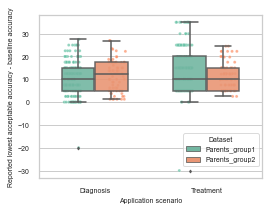

In [323]:
# fig2a, width = 4inch

# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df2_v1p.groupby(["Subject_ID", "Diagnosis_or_Treatment"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Diagnosis_or_Treatment": "clinical_stage",
           "Response": "response_score"
       })
)

df1_subject["clinical_stage"] = df1_subject["clinical_stage"].str.strip().str.capitalize()
#print(df1_subject['clinical_stage'])
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df2_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Add a dashed line at zero so the negative values are meaningful
#plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Boxplot
sns.boxplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2, 'alpha': 0.9},
    palette="Set2"
)

# Stripplot with subject-level points
sns.stripplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.7,
    zorder=1,
    palette="Set2"
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], 
           ["Parents_group1", "Parents_group2"], 
           title="Dataset",
           loc = 'lower right',
           bbox_to_anchor=(1.0, 0.05),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Application scenario")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("fig2a_df2_v1p+v2p_boxer_plots.svg", bbox_inches='tight', format="svg")
plt.show()

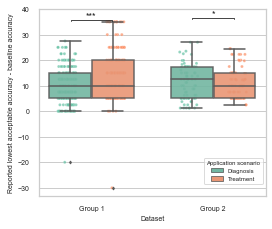

In [3]:
# fig3a v3
# fig2a revised (2026.04.30)
# Categorized by Dataset (x) instead of clinical_stage (hue)
# Added *** significance for Group 1
# Added * significance for Group 2 (19-05-26)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Aggregate to subject-level ----------
df1_subject = (
    df2_v1p.groupby(["Subject_ID", "Diagnosis_or_Treatment"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Diagnosis_or_Treatment": "clinical_stage",
           "Response": "response_score"
       })
)
df1_subject["clinical_stage"] = df1_subject["clinical_stage"].str.strip().str.capitalize()
df1_subject["source"] = "Group 1"

df2_subject = (
    df2_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
# Narrowed width from 4 to 2.8 to bring sets closer
plt.figure(figsize=(3.8, 3.2)) 

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot - Swapped x and hue
sns.boxplot(
    x="source",
    y="response_score",
    hue="clinical_stage",
    data=df_subject,
    order=source_order,
    hue_order=stage_order,
    width=0.7, # Slightly wider bars
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2, 'alpha': 0.9},
    palette="Set2"
)

# Stripplot - Swapped x and hue
sns.stripplot(
    x="source",
    y="response_score",
    hue="clinical_stage",
    data=df_subject,
    order=source_order,
    hue_order=stage_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.7,
    zorder=1,
    palette="Set2"
)

# ---------- Significance Annotation (Group 1: p < .001) ----------
# Center of Group 1 is 0. Female/Male are at roughly +/- 0.17
x1, x2 = -0.17, 0.17 
y_max = df_subject['response_score'].max()
y, h, col = y_max + 0.5, 0.2, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=col)
plt.text((x1+x2)*.5, y+h, "***", ha='center', va='bottom', color=col, fontsize=9)

# ---------- Significance Annotation (Group 2: p < .05) ----------
# Center of Group 2 is 1. Group subplots are at roughly 1 +/- 0.17
x1_g2, x2_g2 = 0.83, 1.17 
# Placed slightly higher than Group 1 bracket to prevent overlapping markers if values are high
y_g2, h_g2 = y_max + 1.2, 0.2

plt.plot([x1_g2, x1_g2, x2_g2, x2_g2], [y_g2, y_g2+h_g2, y_g2+h_g2, y_g2], lw=0.8, c=col)
plt.text((x1_g2+x2_g2)*.5, y_g2+h_g2, "*", ha='center', va='bottom', color=col, fontsize=9)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], 
           ["Diagnosis", "Treatment"], 
           title="Application scenario",
           loc = 'lower right',
           bbox_to_anchor=(1.0, 0.05),
           prop={'size': 6}, 
           title_fontsize=6,
           frameon=True,
           facecolor='white',
           framealpha=0.7
)

# Labels
plt.xlabel("Dataset")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.ylim(top=y_max + 5.2) # Room for stars

plt.tight_layout()
plt.savefig("fig2a_dataset_sig_annotated.svg", bbox_inches='tight', format="svg")
plt.show()

7.2527906329113945
7.097046413502108


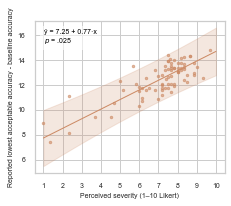

In [170]:
# fig3b with adjusted data, 26-07-25


adjusted = pd.read_csv("fig3b_severity_subject_means.csv")
pred = pd.read_csv("fig3b_severity_prediction_line.csv")


df_avg2 = (
    df2_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 12.72802
slope = 0.77148

x_mean = df_avg2['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig3b_df2_v2p_new_severity_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.4, 2.8))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(adjusted['x_raw'], adjusted['adjusted_response'], color='#cc8963',alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='#cc8963', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='#cc8963', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xticks(range(1, 11))

formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .025"
)


plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()


7.6565656565656575


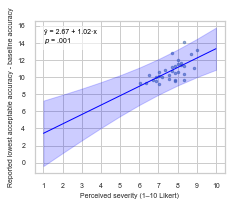

In [173]:
# fig2c, v2c severity accuracy, with adjusted data (26-07-25)

adjusted = pd.read_csv("fig3c_severity_subject_means.csv")
pred = pd.read_csv("fig3c_severity_prediction_line.csv")
#df_raw = pd.read_csv("your_raw_data.csv")


df_avg = (
    df2_v2c.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)
 
intercept = 10.480720  #'Estimate' intercept
slope = 1.024460 #'Estimate' perceived_severity_c
x_mean = df_avg['perceived_severity'].mean()
print(x_mean)
filename = 'fig3c_v2c_severity_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.4, 2.8)) #need to change to 3.5, 4
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(adjusted['x_raw'], adjusted['adjusted_response'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='blue', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='blue', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xticks(range(1, 11))

#intercept_new = intercept - (slope * x_mean)
#print(intercept_new)
intercept_new = 2.67037

formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .001"
)
    
plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg')
plt.show()


7.796875000000001
2.1822585937499994


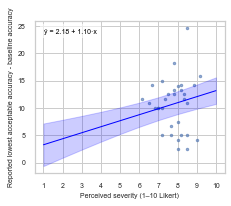

In [41]:
## 26-05-04, removed the outlier subject 66, and re-fit the model 
# re-plot fig2c, v2c severity accuracy 

pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/predictions_severity_df2_v2c_outlier_excluded.csv")
df_v2c = pd.read_excel("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/2_accuracy_outlier_excluded.xlsx")

df_avg = (
    df_v2c.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)
 
intercept = 10.74159  #'Estimate' intercept
slope = 1.09779 #'Estimate' perceived_severity_c
x_mean = df_avg['perceived_severity'].mean()
print(x_mean)
filename = 'fig2c_v2c_severity_v3.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.4, 2.8)) #need to change to 3.5, 4
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['perceived_severity'], df_avg['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='blue', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='blue', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xticks(range(1, 11))

intercept_new = intercept - (slope * x_mean)
print(intercept_new)
#intercept_new = 2.67037

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg')
plt.show()


In [38]:
df_avg

,Subject_ID,perceived_severity,response_score
0,11,7.833333,12.500000
1,12,7.000000,10.000000
2,15,7.833333,18.250000
3,17,8.166667,5.000000
4,19,8.166667,13.333333
5,20,8.000000,7.500000
6,23,7.166667,5.000000
7,24,7.666667,6.666667
8,25,6.500000,10.833333
9,26,7.166667,10.000000


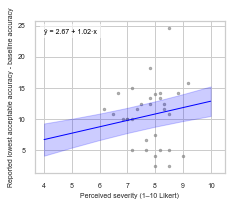

In [37]:
# fig2c_v2c_severity_new (Ignoring minimal X)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load predictions
pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_sig_emm/df2_predictions_severity_v2c_new.csv")

# Aggregate raw data
df_avg = (
    df2_v2c.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

# --- FILTER OUT MINIMAL X VALUE ---
min_x = df_avg['perceived_severity'].min()
df_avg_filtered = df_avg[df_avg['perceived_severity'] > min_x]
pred_filtered = pred[pred['x_raw'] > min_x]

# Regression parameters
intercept_new = 2.67037
slope = 1.024460

filename = 'fig2c_v2c_severity_filtered.svg'

sns.set(style="whitegrid")
plt.figure(figsize=(3.4, 2.8))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Plot filtered raw points
plt.scatter(df_avg_filtered['perceived_severity'], 
            df_avg_filtered['response_score'], 
            alpha=0.6, s=6, color='gray') # Changed to gray for a cleaner look

# Plot filtered regression line and confidence interval
plt.plot(pred_filtered['x_raw'], pred_filtered['predicted'], color='blue', linewidth=1)
plt.fill_between(pred_filtered['x_raw'], pred_filtered['conf.low'], pred_filtered['conf.high'], color='blue', alpha=0.2)

# Labels and Ticks
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")

# Adjust x-axis to start after the ignored minimum
plt.xticks(range(int(min_x) + 1, 11))
plt.xlim(min_x + 0.5, 10.5) 

# Annotation
formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"
plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg', bbox_inches='tight')
plt.show()

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


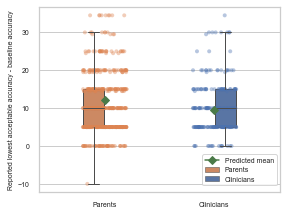

In [143]:
# fig2d, v2p+v2c differences 

df = pd.read_excel("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/combined_v5_finalver_v2p+v2c/2_combined_data_accuracy_v5.xlsx")
pred = pd.read_csv("df2_v5_group.csv")

# --- Plot setup ---
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Define a color palette for groups
palette = sns.color_palette("deep", n_colors=df["group"].nunique())[::-1]

# --- Layer 1: Raw data (jittered points) ---
sns.stripplot(
    data=df,
    x="group", y="response_score",
    color="gray", palette=palette, 
    alpha=0.4, size=4,
    jitter=0.2, dodge=False, zorder=1,
    legend=False
)

#target_order = ['Clinicians', 'Parents']

# --- Layer 2: Boxplot (group summary) ---
sns.boxplot(
    data=df, x="group", y="response_score",
    palette=palette, hue='group',
    width=0.4, color="lightgray",
    showfliers=False, zorder=2,
    linewidth=1
)

# --- Layer 3: Model-predicted means + 95% CI ---


if 'pred' in globals():
    for i, row in pred.iterrows():
        # Plot diamond marker
        plt.plot(row["x"], row["predicted"], 
                marker="D", markersize=5, 
                color="#4a7a48", zorder=10,
                label="Predicted mean" if i == 0 else "")
    
    # Simple legend with only predicted mean
    plt.legend(bbox_to_anchor=(1, 0.02), loc='lower right', fontsize=7,frameon=True)


# --- Labels and layout ---

plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xlabel("")
#plt.title("Raw data, group distributions, and model-adjusted means", fontsize=11)
plt.tight_layout()
plt.savefig('fig2d_df2_v5_group_effects.svg',bbox_inches='tight')
plt.show()


Point-data groups: ['Clinicians' 'Parents']
Prediction groups: ['Clinicians' 'Parents']


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:84: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


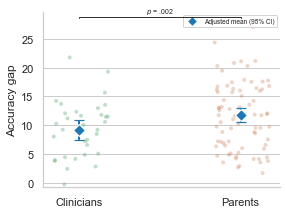

In [229]:
# new fig3d v2p-v2c group difference (26-07-29)

from matplotlib.lines import Line2D

# -------------------------------------------------
# Load adjusted participant points and EMMs
# -------------------------------------------------

df = pd.read_csv(
    "fig3d_accuracy_v2p_v2c_adjusted_participant_points.csv"
)

pred = pd.read_csv(
    "fig3d_accuracy_v2p_v2c_estimated_marginal_means.csv"
)

# These labels must match the values in the CSV files
group_order = ["Clinicians", "Parents"]

# Check labels if necessary
print("Point-data groups:", df["group"].unique())
print("Prediction groups:", pred["group"].unique())

# Explicit ordering
df["group"] = pd.Categorical(
    df["group"],
    categories=group_order,
    ordered=True
)

pred["group"] = pd.Categorical(
    pred["group"],
    categories=group_order,
    ordered=True
)

df = df.sort_values("group")
pred = pred.sort_values("group")

# -------------------------------------------------
# Colors
# -------------------------------------------------

point_palette = {
    "Clinicians": "#52A167",  # green
    "Parents": "#CC8963"      # orange
}

estimate_color = "#2077B4"   # blue

# -------------------------------------------------
# Plot setup
# -------------------------------------------------

sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(4, 3))

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 7,
    "axes.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5
})

# -------------------------------------------------
# Layer 1: adjusted participant-level points
# -------------------------------------------------

sns.stripplot(
    data=df,
    x="group",
    y="adjusted_response",
    order=group_order,
    palette=point_palette,
    alpha=0.35,
    size=4,
    jitter=0.18,
    edgecolor="none",
    zorder=1,
    ax=ax
)

# Numeric locations used internally by Seaborn
position_map = {
    group: position
    for position, group in enumerate(group_order)
}

# -------------------------------------------------
# Layer 2: model-adjusted means and 95% CIs
# -------------------------------------------------

for _, row in pred.iterrows():

    group_name = str(row["group"])
    xpos = position_map[group_name]

    lower_error = (
        row["predicted"] - row["conf.low"]
    )

    upper_error = (
        row["conf.high"] - row["predicted"]
    )

    ax.errorbar(
        x=xpos,
        y=row["predicted"],
        yerr=np.array([
            [lower_error],
            [upper_error]
        ]),
        fmt="D",
        markersize=8,
        markerfacecolor=estimate_color,
        markeredgecolor="white",
        markeredgewidth=1.2,
        color=estimate_color,
        linewidth=2,
        capsize=5,
        zorder=10
    )

# -------------------------------------------------
# Model-based significance annotation
# -------------------------------------------------

y_max = max(
    df["adjusted_response"].max(),
    pred["conf.high"].max()
)

bracket_y = y_max + 0.8
bracket_height = 0.25

ax.plot(
    [0, 0, 1, 1],
    [
        bracket_y - bracket_height,
        bracket_y,
        bracket_y,
        bracket_y - bracket_height
    ],
    color="black",
    linewidth=0.8,
    zorder=12
)

ax.text(
    0.5,
    bracket_y + 0.08,
    r"$p$ = .002",
    ha="center",
    va="bottom",
    fontsize=7
)

# Leave space for the significance bracket
ax.set_ylim(
    bottom=min(
        0,
        df["adjusted_response"].min() - 0.5
    ),
    top=bracket_y + 0.8
)

# -------------------------------------------------
# Labels
# -------------------------------------------------

ax.set_ylabel(
    "Accuracy gap"
)

ax.set_xlabel("")

# -------------------------------------------------
# Legend
# -------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor=estimate_color,
        markeredgecolor="white",
        markersize=7,
        label="Adjusted mean (95% CI)"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    framealpha=0.85,
    edgecolor="0.8"
)

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "fig3d_adjusted_accuracy_gap.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [40]:
pred.head()

,x,predicted,std.error,conf.low,conf.high,group
0,Clinicians,9.462332,0.862669,7.768420,11.156244,1
1,Parents,12.062101,0.667164,10.752078,13.372124,1


In [47]:
df.head()

,disease,Previous_AI_knowledge_score,perceived_severity,response_type,Gender_corr,response_score,Subject_ID,Digital_usage_score,Age,group
0,pneumonia,2,7,diagnosis,Female,15.0,18,6,42,Parents
1,pneumonia,2,7,treatment,Female,5.0,18,6,42,Parents
2,pneumonia,1,8,diagnosis,Female,0.0,20,2,44,Parents
3,pneumonia,1,8,treatment,Female,5.0,20,2,44,Parents
4,pneumonia,2,7,diagnosis,Female,15.0,22,3,36,Parents


### Figure3: maximal error results
3 figures

In [91]:
df3_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/3_error-rate_final.xlsx')

df3_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/3_error_rate_v2.4.xlsx')

In [92]:
pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df3_v1p_digital.csv")


df_avg3 = (
    df3_v1p.groupby("Subject_ID", as_index=False)
    .agg({
        "Digital_usage_score": "mean",
        "Response": "mean"
    })
)

# -----------------------------
# Observed data
# -----------------------------
x_obs = df_avg3["Digital_usage_score"].values   # original scale
y_obs = df_avg3["Response"].values

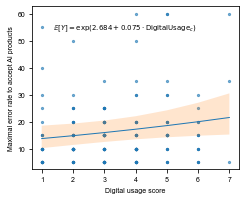

In [63]:
# fig3a, width 3.7 inch 

# -----------------------------
# Load predicted values
# -----------------------------
pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df3_v1p_digital.csv")


df_avg3 = (
    df3_v1p.groupby("Subject_ID", as_index=False)
    .agg({
        "Digital_usage_score": "mean",
        "Response": "mean"
    })
)

# -----------------------------
# Observed data
# -----------------------------
x_obs = df_avg3["Digital_usage_score"].values   # original scale
y_obs = df_avg3["Response"].values

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(3.7,3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Observed data points
plt.scatter(
    x_obs, y_obs,
    alpha=0.6,
    s=5,
    label="Observed data"
)

# Fitted exponential curve
plt.plot(
    pred["Digital_usage_score"],
    pred["fit"],
    linewidth=1,
    label="Fitted effect"
)

# Confidence band
plt.fill_between(
    pred["Digital_usage_score"],
    pred["lwr"],
    pred["upr"],
    alpha=0.2,
    label="95% CI"
)

# Labels and title
plt.xlabel("Digital usage score")
plt.ylabel("Maximal error rate to accept AI products")
#plt.title("Effect of Digital Usage Score on Response")

# -----------------------------
# Formula annotation
# -----------------------------
formula = (
    r"$\mathbb{E}[Y] = \exp(2.684 + 0.075 \cdot \mathrm{DigitalUsage}_c)$"
)

plt.text(
    0.1, 0.9,
    formula,
    transform=plt.gca().transAxes,
    fontsize=7,
    verticalalignment="top"
)

#plt.legend()
filename = 'fig3a_df3_v1p_digital_new.svg'
plt.savefig(filename, format='svg')
plt.show()


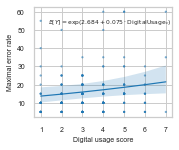

In [74]:
# fig3a, v2 

# -----------------------------
# Load predicted values (Mocked for structure)
# -----------------------------
pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df3_v1p_digital.csv")

# Define a consistent color (using a standard Matplotlib blue or hex)
main_color = '#1f77b4'  

plt.figure(figsize=(2.5, 2.1))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Observed data points - Matched to main_color
plt.scatter(
    x_obs, y_obs,
    color=main_color,
    alpha=0.6,       # Slightly lower alpha helps if points overlap
    s=5,
    edgecolor='none', # Removes outlines for a cleaner look
    label="Observed data"
)

# Fitted exponential curve - Matched to main_color
plt.plot(
    pred["Digital_usage_score"],
    pred["fit"],
    color=main_color,
    linewidth=1.2,   # Slightly thicker line to stand out from points
    label="Fitted effect"
)

# Confidence band - Matched to main_color
plt.fill_between(
    pred["Digital_usage_score"],
    pred["lwr"],
    pred["upr"],
    color=main_color,
    alpha=0.2,       # Keep this low so it stays a "shadow"
    label="95% CI",
    edgecolor='none' # Removes the thin line around the fill area
)

# Labels and title
plt.xlabel("Digital usage score")
plt.ylabel("Maximal error rate")
plt.xticks(range(1, 8))

# Formula annotation
formula = r"$\mathbb{E}[Y] = \exp(2.684 + 0.075 \cdot \mathrm{DigitalUsage}_c)$"

plt.text(
    0.1, 0.9,
    formula,
    transform=plt.gca().transAxes,
    fontsize=6,
    verticalalignment="top"
)

filename = 'fig3a_df3_v1p_digital_new.svg'
plt.tight_layout() # Ensures labels don't get cut off in the 3.7in width
plt.savefig(filename, format='svg')
plt.show()

25.826885804359996


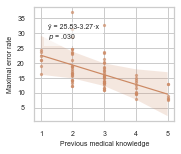

In [182]:
# plot adjusted raw data, 26-07-27

# fig3b, v2p medical_knowledge & error, v2

#pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/0_v2p_n=79_makefigs/df3_medical_knowledge.csv")

adjusted = pd.read_csv("fig4b_medical_subject_means.csv") 
pred = pd.read_csv("fig4b_medical_prediction_line.csv")

main_color = '#cc8963'  

df_avg3 = (
    df3_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Previous_medical_knowledge": "mean",
        "response_score": "mean"
    })
)

intercept = 16.68960
slope = -3.26627
x_mean = 2.797468
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
filename = 'fig4b_df3_v2p_new_medical_error-rate_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.1))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

#plt.scatter(df_avg['Previous_medical_knowledge'], df_avg['response_score'], alpha=0.6, s=25)
plt.scatter(
    adjusted["x_raw"],
    adjusted["adjusted_response"],
    alpha=0.6, s=5,
    color=main_color
)


plt.plot(pred['x_raw'], pred['predicted'], color=main_color, linewidth=1.2)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color=main_color, edgecolor='none', alpha=0.2)
plt.xlabel("Previous medical knowledge")
plt.ylabel("Maximal error rate")
plt.xticks(range(1, 6))


formula_text = (
    f"ŷ = {intercept_new:.2f}{slope:.2f}·x\n"
    f"$p$ = .030"
)

plt.text(
    0.1, 0.85, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg',bbox_inches='tight')
plt.show()


In [162]:
df3_v2p.columns

Index(['Subject_ID', 'Age', 'Gender_corr', 'Number_of_children',
       'Max_child_age', 'If_adult_child', 'Mean_age_children',
       'Education_level', 'Family_income_ordinal',
       'Previous_AI_knowledge_score', 'Digital_usage_score',
       'Previous_medical_knowledge', 'disease', 'experience',
       'perceived_severity', 'response_type', 'response_score',
       'Years_of_education'],
      dtype='object')

In [79]:
# fig3c, v2p-rep & years_of_education, width = 5 

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_replicate_v1p/v2p_rep_new_results/sig_emm/df3_v2p_rep_edu.csv")

df_avg = (
    df3_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Years_of_education": "mean",
        "response_score": "mean"
    })
)

In [80]:
df_avg

,Subject_ID,Years_of_education,response_score
0,18,12.0,57.5
1,20,15.0,5.0
2,22,17.0,15.0
3,24,12.0,40.0
4,26,17.0,15.0
...,...,...,...
74,126,12.0,7.5
75,130,10.0,5.0
76,131,17.0,5.0
77,133,NaN,15.0


In [81]:
pred

,x,predicted,std.error,conf.low,conf.high,group,x_raw
0,-5.576923,23.221370,3.685562,15.935265,30.507474,1,10
1,-4.576923,21.841959,3.162889,15.589144,28.094774,1,11
2,-3.576923,20.462548,2.673886,15.176459,25.748637,1,12
3,-2.576923,19.083137,2.240707,14.653413,23.512861,1,13
4,-1.576923,17.703726,1.901887,13.943826,21.463625,1,14
5,-0.576923,16.324315,1.714316,12.935229,19.713401,1,15
6,0.423077,14.944904,1.727973,11.528819,18.360988,1,16
7,1.423077,13.565493,1.938609,9.732995,17.397990,1,17
8,2.423077,12.186082,2.292558,7.653852,16.718312,1,18
9,3.423077,10.806671,2.734729,5.400299,16.213042,1,19


36.98240769230769
15.576923076923077


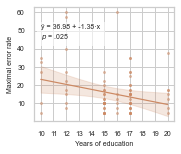

In [82]:
# fig4b, v2p & severity on privacy willingness


intercept = 15.4956
slope = -1.3794

x_mean = df_avg['Years_of_education'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig3c_v2p-rep_edu.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.1))
    
main_color = '#cc8963'

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['Years_of_education'], df_avg['response_score'], alpha=0.45, s=4, color=main_color)

plt.plot(pred['x_raw'], pred['predicted'], color=main_color, linewidth=1.2)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color=main_color, alpha=0.2)
plt.xlabel("Years of education")
plt.ylabel("Maximal error rate")
plt.xticks(range(10, 21))

formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ = .025"
)

plt.text(
    0.05, 0.85, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()

36.982403448
15.57692


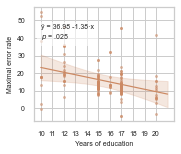

In [186]:
# fig4b, v2p_rep, years of edu, 26-07-27


intercept = 15.4956
slope = -1.3794

x_mean = 15.57692
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

adjusted = pd.read_csv(
    "fig4c_education_adjusted_observations.csv"
)

pred = pd.read_csv(
    "fig4c_education_prediction_line.csv"
)

filename = 'fig4c_v2p-rep_edu_adjusted.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.1))
    
main_color = '#cc8963'

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(adjusted["x_raw"], adjusted["adjusted_response"], alpha=0.45, s=4, color=main_color)

plt.plot(pred['x_raw'], pred['predicted'], color=main_color, linewidth=1.2)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color=main_color, alpha=0.2)
plt.xlabel("Years of education")
plt.ylabel("Maximal error rate")
plt.xticks(range(10, 21))

formula_text = (
    f"ŷ = {intercept_new:.2f} {slope:.2f}·x\n"
    f"$p$ = .025"
)

plt.text(
    0.05, 0.85, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()

In [89]:
df_v1p = (
    df3_v1p.groupby("Subject_ID", as_index=False)
    .agg({
        "Years_of_education": "mean",
        "Response": "mean"
    })
)

In [93]:
pred

,Digital_usage_score,fit,lwr,upr
0,1,13.701944,10.156345,18.485318
1,2,14.772550,11.332986,19.256022
2,3,15.926808,12.449094,20.376039
3,4,17.171255,13.414008,21.980903
4,5,18.512937,14.179520,24.170694
5,6,19.959452,14.759382,26.991628
6,7,21.518991,15.198324,30.468293


In [95]:
pred

,Digital_usage_score,fit,lwr,upr
0,1,13.701944,10.156345,18.485318
1,2,14.772550,11.332986,19.256022
2,3,15.926808,12.449094,20.376039
3,4,17.171255,13.414008,21.980903
4,5,18.512937,14.179520,24.170694
5,6,19.959452,14.759382,26.991628
6,7,21.518991,15.198324,30.468293


In [96]:
df_avg = (
    df3_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Digital_usage_score": "mean",
        "response_score": "mean"
    })
)

In [98]:
df_avg_v1p = (
    df3_v1p.groupby("Subject_ID", as_index=False)
    .agg({
        "Digital_usage_score": "mean",
        "Response": "mean"
    })
)

In [97]:
df_avg

,Subject_ID,Digital_usage_score,response_score
0,18,6,57.5
1,20,2,5.0
2,22,3,15.0
3,24,9,40.0
4,26,5,15.0
...,...,...,...
74,126,4,7.5
75,130,6,5.0
76,131,5,5.0
77,133,8,15.0


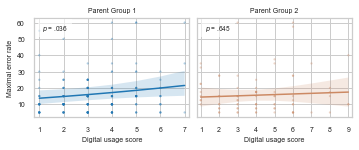

In [113]:
## Fig4A replication study (digital usage score) v2 

# ------------------------------------
# Load prediction files
# ------------------------------------


# Replication parent group (LMM) 
pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df3_v1p_digital.csv")
pred2 = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_replicate_v1p/v2p_rep_new_results/sig_emm/df3_v2p_replicate_digital.csv")


# ------------------------------------
# Colors
# ------------------------------------

color1 = "#2077b4"      # original cohort
color2 = "#cc8963"      # replication cohort

# ------------------------------------
# Figure
# ------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(5.0, 2.1),
    sharex=False,
    sharey=True
)

plt.rcParams.update({
    'font.size':7,
    'font.family':'Arial',
    'axes.titlesize':7,
    'axes.labelsize':7,
    'xtick.labelsize':7,
    'ytick.labelsize':7,
})

############################################################
# Left panel: Original cohort (Gamma GLM)
############################################################

ax = axes[0]

ax.scatter(
    df_avg_v1p['Digital_usage_score'],
    df_avg_v1p['Response'],
    color=color1,
    alpha=0.35,
    s=5,
    edgecolor="none"
)

ax.plot(
    pred["Digital_usage_score"],
    pred["fit"],
    color=color1,
    linewidth=1.5
)

ax.fill_between(
    pred["Digital_usage_score"],
    pred["lwr"],
    pred["upr"],
    color=color1,
    alpha=0.18,
    edgecolor="none"
)

ax.set_title("Parent Group 1")

ax.set_xlabel("Digital usage score")

ax.set_ylabel("Maximal error rate")

ax.set_xlim(0.8, 7.2)
ax.set_xticks(range(1,8))

ax.text(
    0.05,
    0.95,
    r"$p$ = .036", #add p values (> .05; n.s.)
    transform=ax.transAxes,
    fontsize=6.5,
    va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

############################################################
# Right panel: Replication cohort (LMM)
############################################################

ax = axes[1]

ax.scatter(
    df_avg['Digital_usage_score'],
    df_avg['response_score'],
    color=color2,
    alpha=0.35,
    s=5,
    edgecolor="none"
)

ax.plot(
    pred2["x_raw"],
    pred2["predicted"],
    color=color2,
    linewidth=1.5
)

ax.fill_between(
    pred2["x_raw"],
    pred2["conf.low"],
    pred2["conf.high"],
    color=color2,
    alpha=0.18,
    edgecolor="none"
)

ax.set_title("Parent Group 2")

ax.set_xlabel("Digital usage score")

ax.set_xlim(0.8, 9.2)
ax.set_xticks(range(1,10))

ax.text(
    0.05,
    0.95,
    r"$p$ = .645", #or n.s.
    transform=ax.transAxes,
    fontsize=6.5,
    va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
 

plt.tight_layout()

plt.savefig(
    "Fig4a_v1p_v2p_digital-usage.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

##### Fig4a, replot using adjusted data (from v1p glm model & v2p_rep lmm model)

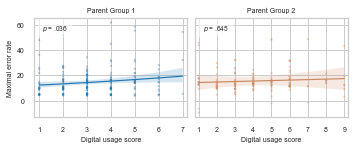

In [181]:
## Fig4A replication study (digital usage score) v2 

# ------------------------------------
# Load prediction files
# ------------------------------------


adjusted = pd.read_csv("fig4a_digital_glm_adjusted_observations.csv")
adjusted2 = pd.read_csv('v2p_fig4a_digital_adjusted_observations.csv')

# Replication parent group (LMM) 
pred = pd.read_csv("fig4a_digital_glm_prediction_line.csv")
pred2 = pd.read_csv("v2p_fig4a_digital_prediction_line.csv")


# ------------------------------------
# Colors
# ------------------------------------

color1 = "#2077b4"      # original cohort
color2 = "#cc8963"      # replication cohort

# ------------------------------------
# Figure
# ------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(5.0, 2.1),
    sharex=False,
    sharey=True
)

plt.rcParams.update({
    'font.size':7,
    'font.family':'Arial',
    'axes.titlesize':7,
    'axes.labelsize':7,
    'xtick.labelsize':7,
    'ytick.labelsize':7,
})

############################################################
# Left panel: Original cohort (Gamma GLM)
############################################################

ax = axes[0]

ax.scatter(
    adjusted["x_raw"],
    adjusted["adjusted_response"],
    color=color1,
    alpha=0.35,
    s=5,
    edgecolor="none",
    zorder=1
)

ax.fill_between(
    pred["x_raw"],
    pred["conf.low"],
    pred["conf.high"],
    color=color1,
    alpha=0.18,
    edgecolor="none",
    zorder=2
)

ax.plot(
    pred["x_raw"],
    pred["predicted"],
    linewidth=1.2,
    color=color1
)

ax.set_title("Parent Group 1")

ax.set_xlabel("Digital usage score")

ax.set_ylabel("Maximal error rate")

ax.set_xlim(0.8, 7.2)
ax.set_xticks(range(1,8))

ax.text(
    0.05,
    0.95,
    r"$p$ = .036", #add p values (> .05; n.s.)
    transform=ax.transAxes,
    fontsize=6.5,
    va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

############################################################
# Right panel: Replication cohort (LMM)
############################################################

ax = axes[1]

ax.scatter(
    adjusted2["x_raw"],
    adjusted2["adjusted_response"],
    color=color2,
    alpha=0.35,
    s=5,
    edgecolor="none"
)


ax.fill_between(
    pred2["x_raw"],
    pred2["conf.low"],
    pred2["conf.high"],
    color=color2,
    alpha=0.18,
    edgecolor="none"
)

ax.plot(
    pred2["x_raw"],
    pred2["predicted"],
    linewidth=1.2,
    color=color2
)

ax.set_title("Parent Group 2")

ax.set_xlabel("Digital usage score")

ax.set_xlim(0.8, 9.2)
ax.set_xticks(range(1,10))

ax.text(
    0.05,
    0.95,
    r"$p$ = .645", #or n.s.
    transform=ax.transAxes,
    fontsize=6.5,
    va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
 

plt.tight_layout()

plt.savefig(
    "Fig4a_v1p_v2p_digital-usage_adjusted.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

### Figure4: privacy results

In [194]:
# load data of all df4 

df4_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/4_privacy_final.xlsx')
df4_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/4_privacy_v2.4.xlsx')
df4_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/4_df4_v2c_final.xlsx')

In [195]:
df4_avg_v1p = pd.DataFrame(df4_v1p.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

In [196]:
df4_avg_v2p = pd.DataFrame(df4_v2p.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

In [197]:
df4_avg_v2c = pd.DataFrame(df4_v2c.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

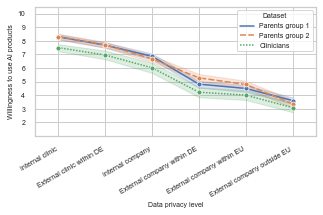

In [7]:
# fig4a, v1p+v2p+v2c line plots, width = 4.9 inch


# 1. Combine dataframes and add a 'Group' identifier
# Replace df_p1, df_p2, and df_cl with your actual variable names
df4_v1p['Group'] = 'Parents group 1'
df4_v2p['Group'] = 'Parents group 2'
df4_v2c['Group'] = 'Clinicians'

# Concatenate them into one master dataframe for plotting
df_combined = pd.concat([df4_v1p, df4_v2p, df4_v2c], ignore_index=True)

# 2. Setup the Plotting Style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.figure(figsize=(4.5, 3))

# 3. Generate the Lineplot
# 'hue' creates the three separate lines based on the 'Group' column
sns.lineplot(
    x='privacy_level', 
    y='response_score', 
    hue='Group', 
    style='Group', # Different line styles (optional)
    errorbar='ci', 
    data=df_combined, 
    marker="o",
    markersize=5
)

# 4. Axis and Label Formatting
plt.xlabel("Data privacy level")
plt.ylabel("Willingness to use AI products")

custom_xticks = [
    "Internal clinic", "External clinic within DE", "Internal company",
    "External company within DE", "External company within EU", "External company outside EU"
]

# Ensure privacy_level is treated as the correct numeric index for xticks
plt.xticks(ticks=range(1, len(custom_xticks) + 1), labels=custom_xticks, rotation=30, ha='right')
plt.xlim(0.5, len(custom_xticks) + 0.5)
plt.yticks(range(2, 11))
plt.ylim(1, 10.5)

# Move legend to a clear spot
plt.legend(title="Dataset", loc='upper right', prop={'size': 7},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig("fig5a_privacy_allgroups.svg", format='svg')
plt.show()

5.382128101265823
6.781645569620253


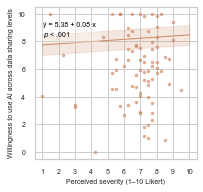

In [85]:
# fig4b, v2p & severity on privacy willingness

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df4_predictions_severity_final.csv")
#df_raw = pd.read_csv("your_raw_data.csv")

color='#cc8963'

df_avg = (
    df4_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 5.929
slope = 0.08064

x_mean = df_avg['perceived_severity'].mean() #6.781646
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig5b_df4_v2p_severity.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.9, 2.8))
    

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['perceived_severity'], df_avg['response_score'], color=color, alpha=0.6, s=6)

plt.plot(pred['x']+ x_mean, pred['predicted'], color=color, linewidth=1)
plt.fill_between(pred['x'] + x_mean, pred['conf.low'], pred['conf.high'], color=color, alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Willingness to use AI across data sharing levels")
plt.xticks(range(1, 11))

formula_text = (
    f"ŷ = {intercept_new:.2f} + {slope:.2f}·x\n"
    f"$p$ < .001"
)


plt.text(
    0.05, 0.9, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.3, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()

In [124]:
adjusted

,Subject_ID,x_centered,x_raw,adjusted_response,partial_residual,observed_response
0,18,0.968354,7.75,8.315679,0.110653,7.958333
1,20,1.468354,8.25,8.324148,0.119123,5.875000
2,22,0.968354,7.75,8.252989,0.047964,2.812500
3,24,0.718354,7.50,8.295883,0.090857,8.770833
4,26,-1.031646,5.75,8.089214,-0.115811,3.333333
...,...,...,...,...,...,...
73,124,0.218354,7.00,8.260027,0.055002,9.979167
74,126,1.218354,8.00,8.344953,0.139928,9.020833
75,130,2.218354,9.00,8.408018,0.202993,8.083333
76,131,0.718354,7.50,8.251152,0.046127,5.166667


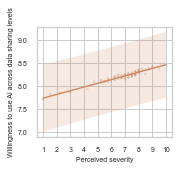

In [126]:
# fig4b, plot adjusted pardata (fitted values + residuals), 26-07-23


# Choose either observation-level or participant-level points

## change to "xx_adjusted_observations.csv" for observational-level points

adjusted = pd.read_csv("severity_subject_means.csv")
pred = pd.read_csv("severity_prediction_line.csv")

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.1))

main_color = "#cc8963"

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# Adjusted participant-level scatter points
plt.scatter(
    adjusted["x_raw"],
    adjusted["adjusted_response"],
    alpha=0.35,
    s=5,
    color=main_color,
    edgecolors="none",
    label="Adjusted participant values"
)

# Marginal prediction line
plt.plot(
    pred["x_raw"],
    pred["predicted"],
    color=main_color,
    linewidth=1.4,
    label="Model prediction"
)

# 95% confidence interval
plt.fill_between(
    pred["x_raw"],
    pred["conf.low"],
    pred["conf.high"],
    color=main_color,
    alpha=0.18,
    edgecolor="none",
    label="95% CI"
)

plt.xlabel("Perceived severity")
plt.ylabel("Willingness to use AI across data sharing levels")
plt.xticks(range(1, 11))

plt.tight_layout()

plt.savefig(
    "df4_severity_adjusted_effect.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [135]:
points['adjusted_willingness'].describe()

count    468.000000
mean       5.976692
std        3.392806
min       -1.546363
25%        3.250108
50%        6.864791
75%        8.944383
max       11.300405
Name: adjusted_willingness, dtype: float64

Observed participant-level perceived-severity range: 1.00–9.50


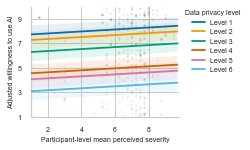

In [156]:
# fig5b, one panel without scatters 

# -------------------------------------------------
# Load data exported from R
# -------------------------------------------------

points = pd.read_csv(
    "severity_privacy_participant_privacy_points.csv"
)

pred = pd.read_csv(
    "severity_privacy_prediction_lines.csv"
)

# Ensure privacy levels have matching types
points["privacy_level"] = points["privacy_level"].astype(str)
pred["privacy_level"] = pred["privacy_level"].astype(str)

level_order = ["1", "2", "3", "4", "5", "6"]

# Distinct, colorblind-friendly colors
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # purple
    "#56B4E9"   # light blue
]

palette = dict(zip(level_order, colors))

# -------------------------------------------------
# Restrict the plot to the observed participant-level
# severity range
# -------------------------------------------------

xmin = points["perceived_severity"].min()
xmax = points["perceived_severity"].max()

x_padding = 0.30
x_lower = max(1, xmin - x_padding)
x_upper = min(10, xmax + x_padding)

print(
    f"Observed participant-level perceived-severity range: "
    f"{xmin:.2f}–{xmax:.2f}"
)

# -------------------------------------------------
# Plot setup
# -------------------------------------------------

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "legend.fontsize": 6.5,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

fig, ax = plt.subplots(figsize=(3.5, 2.1))

# -------------------------------------------------
# Plot each privacy level
# -------------------------------------------------

for level in level_order:

    color = palette[level]

    points_level = points.loc[
        points["privacy_level"] == level
    ].copy()

    pred_level = (
        pred.loc[pred["privacy_level"] == level]
        .sort_values("x_raw")
        .copy()
    )

    # Restrict prediction line and CI to the range shown
    pred_level = pred_level.loc[
        (pred_level["x_raw"] >= x_lower) &
        (pred_level["x_raw"] <= x_upper)
    ]

    # Faint participant-level adjusted observations
    ax.scatter(
        points_level["perceived_severity"],
        points_level["adjusted_willingness"],
        color=color,
        alpha=0.15,
        s=5,
        edgecolors="none",
        zorder=1
    )

    # 95% confidence interval
    ax.fill_between(
        pred_level["x_raw"],
        pred_level["conf.low"],
        pred_level["conf.high"],
        color=color,
        alpha=0.10,
        edgecolor="none",
        zorder=2
    )

    # Model-predicted line
    ax.plot(
        pred_level["x_raw"],
        pred_level["predicted"],
        color=color,
        linewidth=1.8,
        label=f"Level {level}",
        zorder=3
    )

# -------------------------------------------------
# Labels and axes
# -------------------------------------------------

ax.set_xlabel("Participant-level mean perceived severity")
ax.set_ylabel("Adjusted willingness to use AI")

ax.set_xlim(x_lower, x_upper)
ax.set_ylim(1, 10)
ax.set_yticks([1, 3, 5, 7, 9])

# Automatically generate a few readable x-axis ticks
ax.locator_params(axis="x", nbins=5)

ax.legend(
    title="Data privacy level",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    handlelength=1.8,
    prop={'size': 7},      
                  title_fontsize=7)

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "severity_privacy_adjusted_single_panel.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

Observed participant-level perceived-severity range: 1.00–9.50


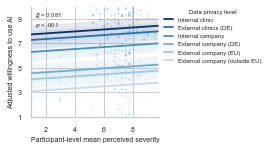

In [193]:
# fig5b, one panel without scatters，update details (26-07-27)

# -------------------------------------------------
# Load data exported from R
# -------------------------------------------------

points = pd.read_csv(
    "severity_privacy_participant_privacy_points.csv"
)

pred = pd.read_csv(
    "severity_privacy_prediction_lines.csv"
)

# Ensure privacy levels have matching types
points["privacy_level"] = points["privacy_level"].astype(str)
pred["privacy_level"] = pred["privacy_level"].astype(str)

level_order = ["1", "2", "3", "4", "5", "6"]

privacy_labels = {
    "1": "Internal clinic",
    "2": "External clinics (DE)",
    "3": "Internal company",
    "4": "External company (DE)",
    "5": "External company (EU)",
    "6": "External company (outside EU)"
}

colors = [
    "#08306B",
    "#2171B5",
    "#4292C6",
    "#6BAED6",
    "#9ECAE1",
    "#C6DBEF"
]

palette = dict(zip(level_order, colors))

# -------------------------------------------------
# Restrict the plot to the observed participant-level
# severity range
# -------------------------------------------------

xmin = points["perceived_severity"].min()
xmax = points["perceived_severity"].max()

x_padding = 0.30
x_lower = max(1, xmin - x_padding)
x_upper = min(10, xmax + x_padding)

print(
    f"Observed participant-level perceived-severity range: "
    f"{xmin:.2f}–{xmax:.2f}"
)

# -------------------------------------------------
# Plot setup
# -------------------------------------------------

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 6,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

fig, ax = plt.subplots(figsize=(3.8, 2.1))

# -------------------------------------------------
# Plot each privacy level
# -------------------------------------------------

for level in level_order:

    color = palette[level]

    points_level = points.loc[
        points["privacy_level"] == level
    ].copy()

    pred_level = (
        pred.loc[pred["privacy_level"] == level]
        .sort_values("x_raw")
        .copy()
    )

    # Restrict prediction line and CI to the range shown
    pred_level = pred_level.loc[
        (pred_level["x_raw"] >= x_lower) &
        (pred_level["x_raw"] <= x_upper)
    ]

    # Faint participant-level adjusted observations
    ax.scatter(
        points_level["perceived_severity"],
        points_level["adjusted_willingness"],
        color=color,
        alpha=0.15,
        s=5,
        edgecolors="none",
        zorder=1
    )

    # 95% confidence interval
    ax.fill_between(
        pred_level["x_raw"],
        pred_level["conf.low"],
        pred_level["conf.high"],
        color=color,
        alpha=0.10,
        edgecolor="none",
        zorder=2
    )

    # Model-predicted line
    ax.plot(
        pred_level["x_raw"],
        pred_level["predicted"],
        color=color,
        linewidth=1.8,
        label=privacy_labels[level],
        zorder=3
    )

# -------------------------------------------------
# Labels and axes
# -------------------------------------------------

ax.set_xlabel("Participant-level mean perceived severity")
ax.set_ylabel("Adjusted willingness to use AI")

ax.set_xlim(x_lower, x_upper)
ax.set_ylim(1, 10)
ax.set_yticks([1, 3, 5, 7, 9])

# Automatically generate a few readable x-axis ticks
ax.locator_params(axis="x", nbins=5)

ax.legend(
    title="Data privacy level",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    handlelength=1.5,
    prop={'size': 6},      
                  title_fontsize=6)

sns.despine(ax=ax)

plt.text(
    0.03,
    0.97,
    r"$\beta$ = 0.081" "\n"
    r"$p$ < .001",
    transform=ax.transAxes,
    fontsize=6,
    ha="left",
    va="top"
)

plt.tight_layout()

plt.savefig(
    "fig5b_severity_privacy_adjusted.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

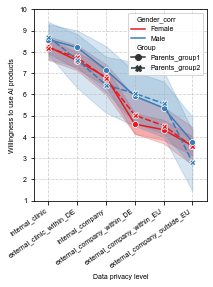

In [14]:
# fig4c, gender plots for two parents group 

# Add a label to each dataset before merging
df4_avg_v1p['Group'] = 'Parents group 1'
df4_avg_v2p['Group'] = 'Parents group 2'

# Combine them
df_combined = pd.concat([df4_avg_v1p, df4_avg_v2p])

plt.figure(figsize=(3, 4))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# hue='Gender_corr' keeps colors for Male/Female
# style='Group' gives different line styles for Parents/Clinicians
sns.lineplot(x='privacy_level', y='response_score', errorbar='ci', 
             hue='Gender_corr', style='Group', markers=True, dashes=True,
             data=df_combined, palette='Set1', markersize=6)

plt.xlabel("Data privacy level")2
plt.ylabel("Willingness to use AI products")
#plt.title("Willingness by Privacy Level: Parents vs. Clinicians")

# Adjusting the legend to show both Gender and Group clearly
#plt.legend(title="Gender & Group", loc='upper left', bbox_to_anchor=(1, 1))

custom_xticks = ["internal clinic","external clinic within DE",'internal company',
                 'external_company_within_DE','external_company_within_EU','external_company_outside_EU']

plt.xticks(ticks=range(1, len(custom_xticks) + 1), labels=custom_xticks, rotation=35, ha='right')
plt.xlim(0.5, len(custom_xticks)+0.5)
plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("fig4c_v1p+v2p_gender_privacy.svg", format='svg')
plt.show()

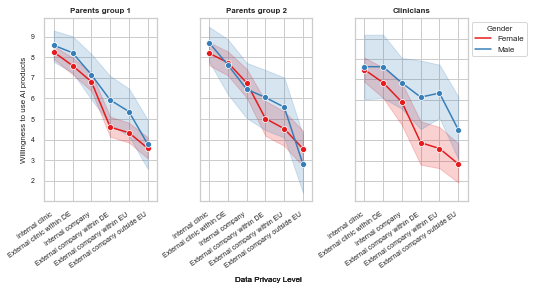

In [8]:
# 1. Setup global style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial',
    'axes.titlesize': 8, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7
})

# 2. Define labels
#custom_xticks = ["internal_clinic", "external_clinic_within_DE", "internal_company",
 #                "external_company_within_DE", "external_company_within_EU", "external_company_outside_EU"]
custom_xticks = [
    "Internal clinic", "External clinic within DE", "Internal company",
    "External company within DE", "External company within EU", "External company outside EU"
]

# 3. Create the figure with 2 subplots (1 row, 2 columns)
# sharey=True is critical to compare the "height" of willingness between groups
fig, axes = plt.subplots(1, 3, figsize=(7.4, 4), sharey=True)

# Define your dataframes and their titles
data_list = [df4_avg_v1p, df4_avg_v2p, df4_avg_v2c] 
titles = ["Parents group 1", "Parents group 2", "Clinicians"]

target_order = ['Female', 'Male']

for i, ax in enumerate(axes):
    # Plotting
    sns.lineplot(x='privacy_level', y='response_score', hue='Gender_corr', hue_order=target_order,
                 data=data_list[i], marker="o", markersize=6, palette='Set1', 
                 errorbar='ci', ax=ax)
    
    # Formatting
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks(range(1, len(custom_xticks) + 1))
    ax.set_xticklabels(custom_xticks, rotation=35, ha='right')
    ax.set_xlim(0.5, len(custom_xticks) + 0.5)
    ax.set_yticks(range(1, 11))
    
    fig.text(0.5, 0.02, 'Data Privacy Level', ha='center', fontsize=8)
    
    if i == 0 or i == 1:
        ax.set_ylabel("Willingness to use AI products")
        ax.get_legend().remove() # Remove legend from first plot
    else:
        ax.set_ylabel("") # Hide Y-label for the second plot
        # Place legend outside the second plot
        ax.legend(title="Gender", loc='upper left', 
                  bbox_to_anchor=(1, 1),prop={'size': 8},      
                  title_fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("fig5c_privacy_comparison_subplots.svg", format='svg', bbox_inches='tight')
plt.show()

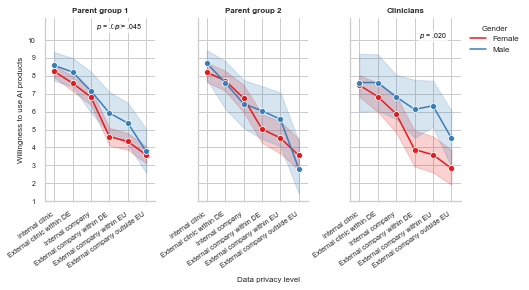

In [199]:
# fig5c, with added sig. p values at privacy levels (26-07-28)

# -------------------------------------------------
# 1. Global style
# -------------------------------------------------

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 7,
    "font.family": "Arial",
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# -------------------------------------------------
# 2. Privacy-level labels
# -------------------------------------------------

custom_xticks = [
    "Internal clinic",
    "External clinic within DE",
    "Internal company",
    "External company within DE",
    "External company within EU",
    "External company outside EU"
]

# -------------------------------------------------
# 3. Data and panel titles
# -------------------------------------------------

data_list = [
    df4_avg_v1p,
    df4_avg_v2p,
    df4_avg_v2c
]

titles = [
    "Parent group 1",
    "Parent group 2",
    "Clinicians"
]

target_order = ["Female", "Male"]

# Model-based EMM gender contrasts:
# dictionary structure = panel index: {privacy level: p-value}
significant_results = {
    0: {
        4: 0.010,
        5: 0.045
    },
    1: {
        # No significant gender contrasts
    },
    2: {
        5: 0.020
    }
}

# -------------------------------------------------
# 4. Helper function for p-value formatting
# -------------------------------------------------

def format_p_value(p_value):
    """Return journal-style p-value text."""
    if p_value < 0.001:
        return r"$p$ < .001"

    return rf"$p$ = {p_value:.3f}".replace("0.", ".")


def add_p_value_annotation(
    ax,
    data,
    privacy_level,
    p_value,
    vertical_offset=0.45
):
    """
    Add a p-value above the data at a specified privacy level.
    """

    level_data = data.loc[
        data["privacy_level"] == privacy_level,
        "response_score"
    ].dropna()

    if len(level_data) == 0:
        return

    # Position annotation above the highest point at this level
    y_position = level_data.max() + vertical_offset

    ax.text(
        privacy_level,
        y_position,
        format_p_value(p_value),
        ha="center",
        va="bottom",
        fontsize=7,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
            pad=1.0
        ),
        zorder=10
    )


# -------------------------------------------------
# 5. Create three-panel figure
# -------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.4, 4),
    sharey=True
)

for i, ax in enumerate(axes):

    current_data = data_list[i]

    # ---------------------------------------------
    # Gender lines with confidence intervals
    # ---------------------------------------------

    sns.lineplot(
        data=current_data,
        x="privacy_level",
        y="response_score",
        hue="Gender_corr",
        hue_order=target_order,
        marker="o",
        markersize=6,
        palette="Set1",
        errorbar="ci",
        ax=ax
    )

    # ---------------------------------------------
    # Add significant EMM comparison p-values
    # ---------------------------------------------

    for privacy_level, p_value in significant_results[i].items():
        add_p_value_annotation(
            ax=ax,
            data=current_data,
            privacy_level=privacy_level,
            p_value=p_value,
            vertical_offset=0.45
        )

    # ---------------------------------------------
    # Panel formatting
    # ---------------------------------------------

    ax.set_title(
        titles[i],
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_xticks(
        range(1, len(custom_xticks) + 1)
    )

    ax.set_xticklabels(
        custom_xticks,
        rotation=35,
        ha="right"
    )

    ax.set_xlim(
        0.5,
        len(custom_xticks) + 0.5
    )

    # Extra space above 10 for annotations
    ax.set_ylim(1, 11.2)
    ax.set_yticks(range(1, 11))

    # ---------------------------------------------
    # Y-axis labels and legend
    # ---------------------------------------------

    if i == 0:
        ax.set_ylabel(
            "Willingness to use AI products"
        )

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    elif i == 1:
        ax.set_ylabel("")

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    else:
        ax.set_ylabel("")

        ax.legend(
            title="Gender",
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            prop={"size": 8},
            title_fontsize=8,
            frameon=False
        )

# -------------------------------------------------
# 6. Shared x-axis label
# -------------------------------------------------

fig.text(
    0.5,
    0.02,
    "Data privacy level",
    ha="center",
    fontsize=8
)

# -------------------------------------------------
# 7. Layout and export
# -------------------------------------------------

sns.despine()

plt.tight_layout()
plt.subplots_adjust(
    bottom=0.30,
    right=0.86
)

plt.savefig(
    "fig5c_privacy_comparison_subplots_pvalues.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

### Figure5: decision plots
6 figures

In [114]:
# load data for figure5

df1 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/5_decision_final.xlsx')
df2 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/5_decision_v2.4.xlsx')
df3 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/5_decision_v3_new.xlsx')


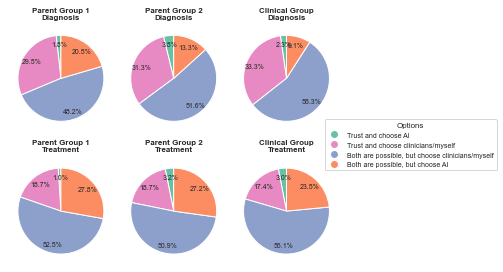

In [118]:
# fig5a (width=4.5 inch) / 7.3 inch


# 1. Standardize and Combine
# Use 'response' as the universal column name for all 3 groups
df1_plot = df1.rename(columns={
    'Response': 'response', 
    'Diagnosis_or_Treatment': 'response_type'
}).copy()

df1_plot["group"] = "Parent Group 1"
df1_plot["clinical_stage"] = df1_plot["response_type"].str.strip().str.capitalize()

df2_plot = df2.rename(columns={'response_score': 'response'}).copy() # Ensure df2 uses 'response'
df2_plot["group"] = "Parent Group 2"
df2_plot["clinical_stage"] = df2_plot["response_type"].str.strip().str.capitalize()

df3_plot = df3.rename(columns={'response_score': 'response'}).copy() # Ensure df3 uses 'response'
df3_plot["group"] = "Clinical Group"
df3_plot["clinical_stage"] = df3_plot["response_type"].str.strip().str.capitalize()

df_plot = pd.concat([df1_plot, df2_plot, df3_plot], ignore_index=True)

# 2. Define Color Mapping (Keys must match the values in the 'response' column)
color_map = {
    "A": "#66c2a5", "B": "#e78ac3", "C": "#8da0cb", "D": "#fc8d62"
}


# 4. Plotting Grid
stages = ["Diagnosis", "Treatment"]
groups = ["Parent Group 1", "Parent Group 2", "Clinical Group"]

plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial',
    'axes.titlesize': 8, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7
})

count_data = (
    df_plot.groupby(["group", "clinical_stage", "response"])
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(len(stages), len(groups), figsize=(7.4, 4.5))

for i, stage in enumerate(stages):
    for j, grp in enumerate(groups):
        ax = axes[i, j]
        
        subset = count_data[(count_data["clinical_stage"] == stage) & (count_data["group"] == grp)]
        #n_val = n_sizes[(n_sizes["clinical_stage"] == stage) & (n_sizes["group"] == grp)]["total_n"].values
        #current_n = n_val[0] if len(n_val) > 0 else 0
        
        if not subset.empty:
            # Crucial: Use 'response' here to match color_map keys
            subset = subset.sort_values("response")
            current_colors = [color_map[res] for res in subset["response"]]
            
            ax.pie(
                subset["count"],
                #labels=subset["response"],
                autopct="%1.1f%%",
                startangle=90,
                colors=current_colors,
                pctdistance=0.80,
                textprops={'fontsize': 7}
            )
            
        
        ax.set_title(f"{grp}\n{stage}", fontsize=8, fontweight='bold')

# 5. Legend and Output

# Create a mapping for descriptive labels
label_map = {
    "A": "Trust and choose AI",
    "B": "Trust and choose clinicians/myself",
    "C": "Both are possible, but choose clinicians/myself",
    "D": "Both are possible, but choose AI"
}

# Update the legend generator
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               label=label_map[k], # Use the map here
               markerfacecolor=v, markersize=8) 
    for k, v in color_map.items()
]

#legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f"{k}",
#                              markerfacecolor=v, markersize=10) for k, v in color_map.items()]

fig.legend(handles=legend_elements, title="Options", loc="center right", 
           bbox_to_anchor=(1.05, 0.5), title_fontsize=8, fontsize=7, frameon=True)

#plt.suptitle("Comparative Choice Distribution Across All Groups", fontsize=14, y=0.98)
#plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.subplots_adjust(
    right=0.75,  # Leaves room for your legend on the right
    top=0.9,
    bottom=0.1,
    wspace=0.05, # Very small horizontal gap
    hspace=0.05   # Small vertical gap
)

plt.savefig('fig5a_df5_pie_chart_allgroups.svg', format='svg', bbox_inches='tight')
plt.show()

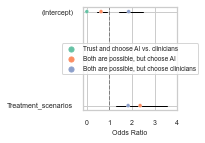

In [214]:
# fig5b (width=2.9 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/df5_v1p_significant_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "Trust and choose AI vs. clinicians"
    elif term.startswith("muC_"):
        return "Both are possible, but choose clinicians"
    elif term.startswith("muD_"):
        return "Both are possible, but choose AI"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "Diagnosis_or_Treatmenttreatment": "Treatment_scenarios",
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.6, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(loc='center',fontsize=6.5, markerscale=0.85)

plt.tight_layout()
plt.savefig('fig5b_df5_v1p.svg', bbox_inches='tight',format='svg')
plt.show()


No handles with labels found to put in legend.


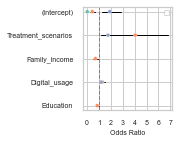

In [298]:
# fig5c (width=3.4 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df5_v2p_rep_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "Family_income_ordinal_c": "Family_income",
    "Years_of_education_c": "Education"
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.5, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3,
    legend=False
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 6},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('df5_v2p_rep.svg', format='svg', bbox_inches='tight')
plt.show()


No handles with labels found to put in legend.


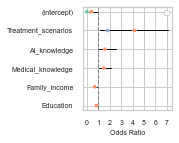

In [297]:
# fig3d, v2p all 2.5 inch (2.8 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/df5_v2p_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Family_income_ordinal_c": "Family_income",
    "Years_of_education_c": "Education",
    "Previous_medical_knowledge_c": "Medical_knowledge",
    "Previous_AI_knowledge_score_c":"AI_knowledge"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.5, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3,
    legend=False
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 6},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('fig5d_df5_v2p.svg', format='svg', bbox_inches='tight')
plt.show()


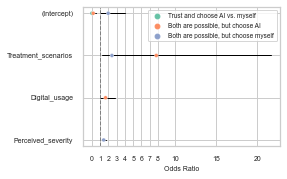

In [216]:
# fig5e, v2c, width = 4 (legend out)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_sig_emm/df5_v2c_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "Trust and choose AI vs. myself"
    elif term.startswith("muC_"):
        return "Both are possible, but choose myself"
    elif term.startswith("muD_"):
        return "Both are possible, but choose AI"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "perceived_severity_c": "Perceived_severity"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(4, 2.5))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7,8,10,15,20])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 6.5}, markerscale=0.8)

plt.tight_layout()
plt.savefig('fig5e_df5_v2c.svg', format='svg', bbox_inches='tight')
plt.show()


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 


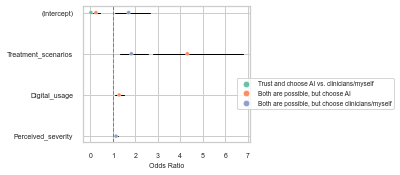

In [226]:
# fig5f, v2c_v2p, width = 3.4 

# fig5e, v2c, width = 4 (legend out)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/df5_v2p+v2c_significant_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "Trust and choose AI vs. clinicians/myself"
    elif term.startswith("muC_"):
        return "Both are possible, but choose clinicians/myself"
    elif term.startswith("muD_"):
        return "Both are possible, but choose AI"
    else:
        return None
    

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "perceived_severity_c": "Perceived_severity"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(3, 2.5))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(0.9, 0.5),prop={'size': 6.5}, markerscale=0.8)

plt.tight_layout()
plt.savefig('fig5f_df5_v2c-v2p.svg', format='svg', bbox_inches='tight')
plt.show()
